# Static Move Prediction Draft

## Setup Environment && Load Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dataclasses import dataclass

import mlflow
import optuna

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from chesswinnerprediction.static_move.models.static_move_base import StaticMoveBaseModel

from config import RANDOM_STATE
from chesswinnerprediction.static_move.utils import load_train_valid_test, setup_mlflow

## Setup MLflow

In [3]:
setup_mlflow(experiment_name="Static Move Prediction")

2024/08/15 22:08:49 INFO mlflow.tracking.fluent: Experiment with name 'Static Move Prediction' does not exist. Creating a new experiment.


## Load Data

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test()

## Optuna

In [5]:
def get_model(trial: optuna.Trial, model_type):
    if model_type == RandomForestClassifier.__name__:
        model = RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
            n_estimators=trial.suggest_int("forest_n_estimators", 10, 100),
            max_depth=trial.suggest_int("forest_max_depth", 2, 20),
            min_samples_leaf=trial.suggest_int("forest_min_samples_leaf", 1, X_train.shape[0]),
            max_features=trial.suggest_categorical("forest_max_features", [None, "sqrt", "log2"]),
        )
    elif model_type == GradientBoostingClassifier.__name__:
        model = GradientBoostingClassifier(
            n_iter_no_change=5,
            tol=1e-3,
            random_state=RANDOM_STATE,
            learning_rate=trial.suggest_float("boosting_learning_rate", 1e-3, 1e-1, log=True),
            n_estimators=trial.suggest_int("boosting_n_estimators", 2, 100),
            max_depth=trial.suggest_int("boosting_max_depth", 2, 16),
            min_samples_leaf=trial.suggest_int(f"boosting_min_samples_leaf", 1, X_train.shape[0]),
            max_features=trial.suggest_categorical("boosting_max_features", [None, "sqrt", "log2"]),
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model

In [6]:
@dataclass
class BestModel:
    trial: optuna.Trial = None
    score: float = 0.0
    run_id: str = ""

In [7]:
class Objective:
    def __init__(self, parent_run_id):
        self.parent_run_id = parent_run_id
        self.model_types = [RandomForestClassifier.__name__, GradientBoostingClassifier.__name__]
        self._best_models = self.__generate_best_model_dict()
        
    def __call__(self, trial: optuna.Trial):
        model_type = trial.suggest_categorical("model_type", self.model_types)

        estimator = get_model(trial, model_type)
        model = StaticMoveBaseModel(estimator=estimator)
        model.fit(X_train, y_train)

        model.score(X_valid, y_valid)
        self.log_trial(trial, model)
        
        return model.balanced_accuracy
    
    def log_trial(self, trial, model: StaticMoveBaseModel):
        score = model.balanced_accuracy
        model_type = trial.params["model_type"]
        if score > self._best_models[model_type].score:
            self._best_models[model_type].score = score
            self._best_models[model_type].trial = trial
        
        
        run_id = self._best_models[model_type].run_id
        with mlflow.start_run(nested=True, run_id=run_id, parent_run_id=self.parent_run_id) as model_run:
            with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}", parent_run_id=model_run.info.run_id):
                mlflow.log_params(trial.params)
                model.log_trial()
                
        
    def __generate_best_model_dict(self):
        best_models = {}
        for model_type in self.model_types:
            with mlflow.start_run(nested=True, run_name=model_type, parent_run_id=self.parent_run_id) as model_run:
                best_models[model_type] = BestModel(run_id=model_run.info.run_id)
        return best_models

In [8]:
study = optuna.create_study(direction="maximize", study_name="Static Move Prediction")

[I 2024-08-15 22:08:57,740] A new study created in memory with name: Static Move Prediction


In [9]:
with mlflow.start_run(run_name="Optuna") as main_run:
    objective = Objective(parent_run_id=main_run.info.run_id)
    study.optimize(objective, n_trials=24, show_progress_bar=True)

  0%|          | 0/24 [00:00<?, ?it/s]

[I 2024-08-15 22:08:59,098] Trial 0 finished with value: 0.3333333333333333 and parameters: {'model_type': 'GradientBoostingClassifier', 'boosting_n_estimators': 35, 'boosting_max_depth': 4, 'boosting_min_samples_leaf': 122718, 'boosting_max_features': 'log2'}. Best is trial 0 with value: 0.3333333333333333.
[I 2024-08-15 22:08:59,864] Trial 1 finished with value: 0.3333333333333333 and parameters: {'model_type': 'RandomForestClassifier', 'forest_n_estimators': 34, 'forest_max_depth': 10, 'forest_min_samples_leaf': 81247, 'forest_max_features': None}. Best is trial 0 with value: 0.3333333333333333.
[I 2024-08-15 22:09:00,739] Trial 2 finished with value: 0.3333333333333333 and parameters: {'model_type': 'RandomForestClassifier', 'forest_n_estimators': 58, 'forest_max_depth': 5, 'forest_min_samples_leaf': 97614, 'forest_max_features': 'log2'}. Best is trial 0 with value: 0.3333333333333333.
[I 2024-08-15 22:09:01,437] Trial 3 finished with value: 0.3333333333333333 and parameters: {'mod

In [10]:
from sklearn.metrics import classification_report

In [16]:
best_model = get_model(study.best_trial, study.best_trial.params["model_type"])

In [20]:
best_model.verbose = 3
best_model.tol = 1e-2
best_model.n_iter_no_change = 5

In [21]:
best_model.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           0.8051            4.29m
         2           0.7809            4.22m
         3           0.7618            4.07m
         4           0.7466            3.94m
         5           0.7342            3.85m
         6           0.7242            3.84m
         7           0.7161            3.83m
         8           0.7092            3.79m
         9           0.7034            3.77m
        10           0.6985            3.74m
        11           0.6943            3.71m
        12           0.6909            3.66m
        13           0.6878            3.62m
        14           0.6852            3.58m
        15           0.6829            3.55m
        16           0.6809            3.53m
        17           0.6791            3.49m


GradientBoostingClassifier(max_depth=14, min_samples_leaf=1754, n_estimators=99,
                           n_iter_no_change=5, random_state=42, tol=0.01,
                           verbose=3)

In [22]:
y_pred = best_model.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0-1       0.68      0.69      0.68    364248
         1-0       0.67      0.71      0.69    370765
     1/2-1/2       0.59      0.09      0.15     32426

    accuracy                           0.68    767439
   macro avg       0.65      0.50      0.51    767439
weighted avg       0.67      0.68      0.67    767439



In [24]:
# show feature importance

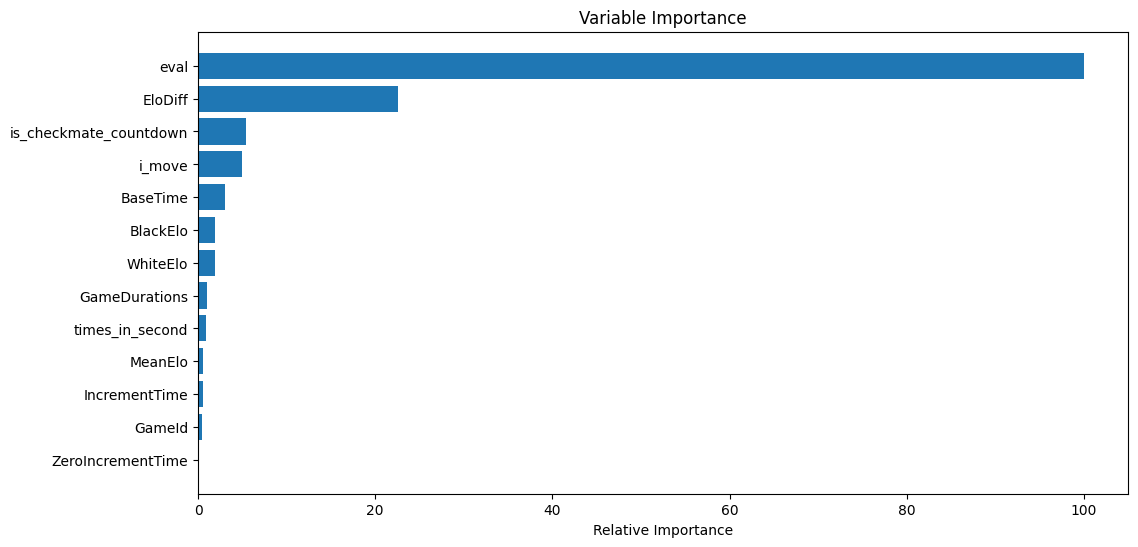

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

feature_importance = best_model.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, X_train.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.show()